

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>





# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [8]:

import pandas as pd
df_instacart_orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
df_products = pd.read_csv('/datasets/products.csv', sep=';')
df_order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
df_aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
df_departments = pd.read_csv('/datasets/departments.csv', sep=';')


In [12]:
df_instacart_orders
df_products
df_order_products
df_aisles
df_departments

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [2]:
df_instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [41]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [40]:
df_order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [39]:
df_aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [38]:
df_departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


## Conclusões

Em princinpio ja conseguimos observar o tamanho do arquivo e valores ausentes a ser corrigidos e analisados, e tambem a distribuição de vendas e entregas.

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [9]:

df_instacart_orders[df_instacart_orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Há linhas duplicadas? Se sim, o que elas têm em comum?

Temos 15 linhas duplicadas a serem analisadas, tendo em comum que todas foram no mesmo dia e no mesmo horario.

In [10]:
# Com base nas suas conclusões,
pedidos_2h_quarta = df_instacart_orders[
    (df_instacart_orders['order_hour_of_day'] == 2) & 
    (df_instacart_orders['order_dow'] == 3)
    ]
print(f"Numero de pedidos às 2h nas quartas-feiras: {len(pedidos_2h_quarta)}")
print(pedidos_2h_quarta.head())


Numero de pedidos às 2h nas quartas-feiras: 121
       order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838    2766110   162084            41          3                  2   
5156    2190225   138285            18          3                  2   
15506    553049    58599            13          3                  2   
18420    382357   120200            19          3                  2   
24691    690242    77357             2          3                  2   

       days_since_prior_order  
4838                     16.0  
5156                     11.0  
15506                     7.0  
18420                    11.0  
24691                     9.0  


O que esse resultado quer dizer?

Que realmente temos 15 pedidos duplicados, que pelo horario seria improvavel ser apenas uma coincidência, ja que e um horario de baixa saida.

In [21]:
# Remova pedidos duplicados
df_instacart_orders = df_instacart_orders.drop_duplicates()

In [23]:
print(f"Duplicatas restantes: {df_instacart_orders.duplicated().sum()}")


Duplicatas restantes: 0


In [5]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(f"Tamanho antes: 478967")
print(f"Tamanho depois:{len(df_instacart_orders)}")

Tamanho antes: 478967
Tamanho depois:478967




Descreva brevemente suas conclusões e o que você fez com elas

Com a analise foi identificada 15 pedidos duplicados, sendo eles registrados todos no mesmo horario e dia, foi facil perceber o erro pois o harario e foram do padrão para pedidos de supermecado, assim percebemos o erro tecnico de sistema.
Removi as duplicatas, deixando assim mas claros os dados..

### DataFrame `products`

In [25]:
# Verifique se há linhas completamente duplicadas
duplicatas_completas = df_products.duplicated()
print(f"Numero de linhas completamente duplicadas: {duplicatas_completas.sum()}")

if duplicatas_completas.sum() > 0:
    print("\nLinhas duplicadas:")
    print(df_products[duplicatas_completas])

Numero de linhas completamente duplicadas: 0


In [11]:
# Verifique apenas IDs dos produtos duplicados
ids_duplicados = df_products['product_id'].duplicated()
print(f"Numero de product_ids duplicados:{ids_duplicados.sum()}")

if ids_duplicados.sum() >0:
    print("\nproduct_ids duplicados:")
    ids_repetidos = df_products[df_products['product_id'].duplicated(keep=False)]
    print(ids_repetidos.sort_values('product_id'))
    

Numero de product_ids duplicados:0


In [13]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
produtos_com_nome = df_products.dropna(subset=['product_name'])

nomes_minusculas = produtos_com_nome['product_name'].str.lower()
nomes_duplicados = nomes_minusculas.duplicated()

print(f"Numero de nomes de produtos duplicados: {nomes_duplicados.sum()}")

if nomes_duplicados.sum() > 0:
    print("\nNomes de produtos duplicados:")
    produtos_duplicados = produtos_com_nome[nomes_minusculas.duplicated(keep=False)]
    print(produtos_duplicados[['product_id', 'product_name']].sort_values('product_name'))
    

Numero de nomes de produtos duplicados: 104

Nomes de produtos duplicados:
       product_id                               product_name
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap
23339       23340  18-in-1 Hemp Peppermint Pure-Castile Soap
19941       19942            Aged Balsamic Vinegar Of Modena
13152       13153            Aged Balsamic Vinegar of Modena
22582       22583         Albacore Solid White Tuna In Water
...           ...                                        ...
40093       40094              Wild Sardines In Spring Water
21366       21367              Wild Sardines in Spring Water
38260       38261           Yams Cut Sweet Potatoes In Syrup
1826         1827           Yams Cut Sweet Potatoes in Syrup
12820       12821                              pumpkin spice

[207 rows x 2 columns]


In [15]:
# Verifique os nomes de produtos duplicados que não estão faltando
produtos_com_nome = df_products.dropna(subset=['product_name'])
nomes_minusculas = produtos_com_nome['product_name'].str.lower()
produtos_nomes_duplicados = produtos_com_nome[nomes_minusculas.duplicated(keep=False)]

print(f"Total de produtos com nomes duplicados(incluindo originais):{len(produtos_nomes_duplicados)}")
print(f"Numero de nomes unicos duplicados:{nomes_minusculas.duplicated().sum()}")

print("\nExemplos de produtos com nomes duplicados")
print(produtos_nomes_duplicados[['product_id', 'product_name']].sort_values('product_name').head(10))


Total de produtos com nomes duplicados(incluindo originais):207
Numero de nomes unicos duplicados:104

Exemplos de produtos com nomes duplicados
       product_id                               product_name
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap
23339       23340  18-in-1 Hemp Peppermint Pure-Castile Soap
19941       19942            Aged Balsamic Vinegar Of Modena
13152       13153            Aged Balsamic Vinegar of Modena
22582       22583         Albacore Solid White Tuna In Water
24830       24831         Albacore Solid White Tuna in Water
515           516                     American Cheese Slices
9037         9038                     American Cheese slices
49530       49531               Anchovy Fillets In Olive Oil
12325       12326               Anchovy Fillets in Olive Oil


### DataFrame `departments`

In [17]:
# Verifique se há linhas completamente duplicadas
df_departments[df_departments.duplicated()]

,department_id,department


In [18]:
# Verifique apenas IDs duplicados de departamentos
ids_duplicados_dept = df_departments['department_id'].duplicated()
print(f"Numero de department_ids duplicados:{ids_duplicados_dept.sum()}")

Numero de department_ids duplicados:0


Descreva brevemente suas conclusões e o que você fez com elas.

Na analise observamos que os dados estão corretos e limpos e sem duplicatas, o departments esta consistentes e unicos.

### DataFrame `aisles`

In [22]:
# Verifique se há linhas completamente duplicadas
df_aisles[df_aisles.duplicated()]

,aisle_id,aisle


In [29]:
# Verifique apenas IDs duplicados de corredorido
ids_duplicados_aisles = df_aisles['aisle_id'].duplicated()
print(f"Numero de aisle_ids duplicados: {ids_duplicados_aisles.sum()}")

if ids_duplicados_aisles.sum() > 0:
    print("\nAisle_ids duplicados:")
    aisles_duplicados = df_aisles[df_aisles['aisle_id'].duplicated(keep=False)]
    print(aisles_duplicados.sort_values('aisle_id'))



Numero de aisle_ids duplicados: 0


Descreva brevemente suas conclusões e o que você fez com elas.

*DataFrame instacart_orders:
Ate agora ja resolvemos a questão das 15 linhas completamente duplicadas em relação aos pedidos, sendo que todos ocorreram no mesmo dia e na mesma hora, logo assim percebendo que era um erro no sistema.
*DataFrame products:
Nao tinha linhas completamente duplicadas, porem tinha 104 nomes de produtos duplicados, onde o problema era a questão de letras maiusculas e minusculas.
*DataFrame departments e aisles:
Sem duplicadas encontradas e dados bem consistentes e unicos.

### DataFrame `order_products`

In [32]:
# Verifique se há linhas completamente duplicadas
df_order_products[df_order_products.duplicated()]


,order_id,product_id,add_to_cart_order,reordered


In [31]:
# Verifique mais uma vez se há outros casos complicados de duplicados
combinacoes_duplicadas = df_order_products[['order_id', 'product_id']].duplicated()
print(f"Numero de combinações order_id + product_id duplicadas: {combinacoes_duplicadas.sum()}")

if combinacoes_duplicadas.sum() > 0:
      print("\nCombinaçoes duplicadas:")
      duplicadas = df_order_products[combinacoes_duplicadas]   
      print(duplicadas.head())
    

Numero de combinações order_id + product_id duplicadas: 0


Descreva brevemente suas concluçoes e o que fez com elas.

Nao a produtos duplicados quando se trata de IDs unicos, e como são os IDS que permite a identificação de cada produto distinta, e pra analise isso e o mas importante.


## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [33]:
# Encontre valores ausentes na coluna 'product_name'
df_products['product_name'].isnull().sum()

1258

Descreva brevemente suas conclusões.

Foi encontrado 1.258 produto sem nome(total de 2,5%) que estão associados ao corredor ID 100 e departamento do ID 21, o problema foi gerado na hora do cadastro.

In [34]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
produtos_sem_nome = df_products[df_products['product_name'].isnull()]
print(produtos_sem_nome['aisle_id'].unique())

[100]


Descreva brevemente suas conclusões.

todos estão no corredor 100, assim sera mas facil para resolver o problema.

In [36]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
produtos_sem_nome = df_products[df_products['product_name'].isnull()]
print(f"Departamentos unicos dos produtos sem nome: {produtos_sem_nome['department_id'].unique()}")
print(f"Todos estão no departamento 21?{(produtos_sem_nome['department_id'] == 21).all()}")


Departamentos unicos dos produtos sem nome: [21]
Todos estão no departamento 21?True


Descreva brevemente suas conclusões.

Todos os 1.258, dando cerca de 2,5% do total cadastrado dos produtos sem nome estao concentratos no corredor ID 100 e no departamento ID 21, assim seguindo um padrao sistematico de dados.

In [12]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
departamento_21 = df_departments[df_departments['department_id'] == 21]
print("Departamento ID 21:")
print(departamento_21)

print("\n" + "="*50 + "\n")

corredor_100 = df_aisles[df_aisles['aisle_id'] == 100]
print("Corredor ID 100:")
print(corredor_100)

Departamento ID 21:
    department_id department
20             21    missing


Corredor ID 100:
    aisle_id    aisle
99       100  missing


Descreva brevemente suas conclusões.
sao produtos com incompletos organizados, e nao erro do sistema; sao produtos que nao todas as infomaçoes.  
    

In [19]:
# Preencha nomes de produtos ausentes com 'Unknown'
df_products['product_name'] = df_products['product_name'].fillna('Unknown')
print(f"Valores ausentes restantes: {df_products['product_name'].isnull().sum()}")
produtos_unknown = df_products[df_products['product_name'] == 'unknown']
print(f"Produtos com nome 'unknown': {len(produtos_unknown)}")

Valores ausentes restantes: 0
Produtos com nome 'unknown': 0


Descreva brevemente suas conclusões e o que você fez com elas.

Na coluna product_name foi encontrado 1.258 produtos 2,5% do total, sem nome com dados ausentes, todos localizados no corredor ID 100(missing) e departamento ID 21(missing), indicando que nao foram erro aleatorios e sim uma forma de catalogar e organizar os produtos com informaçoes incompletas..
Foi preencdido os valores ausente com Unknown, em vez de remover, pois eles representam vendas reais no sistema.

### DataFrame `orders`

In [20]:
# Encontre os valores ausentes
valores_ausentes = df_instacart_orders['days_since_prior_order'].isnull().sum()
print(f"Valores ausente em 'days_since_prior_order': {valores_ausentes}")

pedidos_sem_dias = df_instacart_orders[df_instacart_orders['days_since_prior_order'].isnull()]
print(f"\nPrimeiros 5 pedidos sem 'days_since_prior_order':")
print(pedidos_sem_dias[['order_id', 'user_id', 'order_number', 'days_since_prior_order']].head())

Valores ausente em 'days_since_prior_order': 28819

Primeiros 5 pedidos sem 'days_since_prior_order':
     order_id  user_id  order_number  days_since_prior_order
28     133707   182261             1                     NaN
96     787445    25685             1                     NaN
100    294410   111449             1                     NaN
103   2869915   123958             1                     NaN
104   2521921    42286             1                     NaN


In [21]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
pedidos_sem_dias = df_instacart_orders[df_instacart_orders['days_since_prior_order'].isnull()]

pedidos_problematicos = pedidos_sem_dias[pedidos_sem_dias['order_number'] > 1]

print(f"Total de valores ausentes: {len(pedidos_sem_dias)}")
print(f"Valores ausentes em primeiros pedidos (order_number = 1): {len(pedidos_sem_dias[pedidos_sem_dias['order_number'] == 1])}")
print(f"Valores ausente em pedidos subsequentes (order_number > 1): {len(pedidos_problematicos)}")

Total de valores ausentes: 28819
Valores ausentes em primeiros pedidos (order_number = 1): 28819
Valores ausente em pedidos subsequentes (order_number > 1): 0


Descreva brevemente suas conclusões e o que você fez com elas.

Foi encontrada 28.819 valores ausentes(cerca de 6% do total) na coluna days_since_prior_order. atraves da analise percebesse que os valores ausentes correspondem a primeiros pedidos dos clientes(order_number=1) o que e completamente esperado.
nao tem valores ausente em pedidos subsequentes (order_number > 1), confirmando que os dados esta corretos.
Assim decidi nao preencher esses valores ausentes, pois eles representam uma situação real e logica do negocio.

### DataFrame `order_products`

In [23]:
# Encontre os valores ausentes
valores_ausentes = df_order_products['add_to_cart_order'].isnull().sum()
print(f"Valores ausentes em 'add_to_cart_order': {valores_ausentes}")

produtos_sem_ordem = df_order_products[df_order_products['add_to_cart_order'].isnull()]
print(f"\nPrimeiros 5 produtos sem 'add_to_cart_order':")
print(produtos_sem_ordem[['order_id', 'product_id', 'add_to_cart_order']].head())

pedidos_afetados = produtos_sem_ordem['order_id'].nunique()
print(f"nNumero de pedidos afetados: {pedidos_afetados}")


Valores ausentes em 'add_to_cart_order': 836

Primeiros 5 produtos sem 'add_to_cart_order':
       order_id  product_id  add_to_cart_order
737     2449164        5068                NaN
9926    1968313       43867                NaN
14394   2926893       11688                NaN
16418   1717990        4142                NaN
30114   1959075       42828                NaN
nNumero de pedidos afetados: 70


In [31]:
# Quais são os valores mínimo e máximo dessa coluna?
min_valor = df_order_products['add_to_cart_order'].min()
max_valor = df_order_products['add_to_cart_order'].max()

print(f"Valor minimo: {min_valor}")
print(f"Valor maximo: {max_valor}")

Valor minimo: 1.0
Valor maximo: 64.0


Descreva brevemente suas conclusões.

os valores encontrados variam entre 1 e 64, esse valor maximo de 64 indica que alguns carrinhos são bem grandes, e isso pode esta relacionado aos 836 valores ausentes encontrados, sendo assim tendo uma possivel limitação no sistema ao registrar produtos alem da posição 64.

In [33]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
pedidos_com_valores_ausentes = df_order_products[
    df_order_products['add_to_cart_order'].isnull()
]['order_id'].unique()
print(f"Total de pedidos afetados: {len(pedidos_com_valores_ausentes)}")
print(f"Primeiros 10 IDs dos pedidos afetados:")
print(pedidos_com_valores_ausentes[:10])

pedidos_problematicos = pedidos_com_valores_ausentes


Total de pedidos afetados: 70
Primeiros 10 IDs dos pedidos afetados:
[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093]


In [36]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem

pedidos_problematicos_contagem = df_order_products[
    df_order_products['order_id'].isin(pedidos_problematicos)
].groupby('order_id')['product_id'].count()  
print(f"Numero minimo de produtos nos pedidos afetados:{pedidos_problematicos_contagem.min()}")
print(f"Numero maximo de produtos nos pedidos afetados:{pedidos_problematicos_contagem.max()}")
print(f"Todos os pedidos tem mais de 64 produtos? {(pedidos_problematicos_contagem > 64).all()}")


Numero minimo de produtos nos pedidos afetados:65
Numero maximo de produtos nos pedidos afetados:127
Todos os pedidos tem mais de 64 produtos? True


Descreva brevemente suas conclusões.

a hipotese sobre os 64 itens foi confirmada, todos os 70 pedidos com valores ausentes tem mais de 64 produtos, que tem uma variação entre 65 a 127 que e o maximo de produto.
isso mostra uma limitação tecnica no sistema, que não consegue registrar a ordem sequencial de produtos alem da posição 64, assim se explica que os 836 valores ausentes sao produtos adicionados ao carrinho apos o 64 produto.

In [2]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].fillna(999).astype(int)

print(f"Valores ausentes restantes: {df_order_products['add_to_cart_order'].isnull().sum()}")
print(f"Tipo da coluna: {df_order_products['add_to_cart_order'].dtype}")
print(f"Produtos com valores 999: {(df_order_products['add_to_cart_order'] == 999).sum()}")


Valores ausentes restantes: 0
Tipo da coluna: int64
Produtos com valores 999: 836


Descreva brevemente suas conclusões e o que você fez com elas.

analise mostrou que todos os 70 pedidos afetados tem mais de 64 produtos, que assim levou aos 836 valores ausentes em add_to_cart_order.
confirmando a limitação tecnica no sistema para pedidos acima de 64, entao usamos 999 como um codigo identificador para produtos sem ordem sequencial e assim substitui os valores ausentes em vez de remover.

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados

*Problemas identificados: valores ausentes em add_to_cart_order no total de 836 valores ausentes em 70 pedidos,(sendo resolvido com a substituição por 999:codigo para produtos sem ordemsequencial), converteu o add_to_cart_order para interagi e preservou todos os produtos(vendas reais)mantendo a identificação do padrão
agora temos dados limpos e consistentes, nenhum produto perdido e dados bem estruturados pra manusear.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Duplicados e ausentes de todos os dfs foram investigados e corrigidos conforme o roteiro proposto
</div>




# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [2]:
print("=== Verificação da coluna 'order_hour_of_day' ===")
print(f"Valores minimo e maximo: {df_instacart_orders['order_hour_of_day'].min()} - {df_instacart_orders['order_hour_of_day'].max()}")
print(f"Valores unicos: {sorted(df_instacart_orders['order_hour_of_day'].unique())}")
print(f"Intervalo esperado: 0-23")
print(f"Valores fazem sentindo? {df_instacart_orders['order_hour_of_day'].min() >= 0 and df_instacart_orders['order_hour_of_day'].max() <= 23}")

=== Verificação da coluna 'order_hour_of_day' ===
Valores minimo e maximo: 0 - 23
Valores unicos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Intervalo esperado: 0-23
Valores fazem sentindo? True


In [9]:
print("\n=== Verificação da colunaa 'order_dow' ===")
print(f"Valores minimo e  maximo: {df_instacart_orders['order_dow'].min()} - {df_instacart_orders['order_dow'].max()}")
print(f"Valores unicos: {sorted(df_instacart_orders['order_dow'].unique())}")
print(f"Intervalo esperado: 0-6")
print(f"Valores fazem sentido? {df_instacart_orders['order_dow'].min() >= 0 and df_instacart_orders['order_dow'].max() <= 6}")


=== Verificação da colunaa 'order_dow' ===
Valores minimo e  maximo: 0 - 6
Valores unicos: [0, 1, 2, 3, 4, 5, 6]
Intervalo esperado: 0-6
Valores fazem sentido? True


Escreva suas conclusões aqui
a analise confirmou que as duas colunas estao corretas, order_hour_of_day esta variando corretamente entre o e 23, representando todas as 24 horas do dia.
e order_dow tambem esta com valores corretos entre 0 a 6 representando os 7 dias da semana:
sendo assim tanto o dia quanto a semana estao com horas e dia corretos, sem valores inconsistentes.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Valores das colunas de dias e horas validados adequadamente.
</div>

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

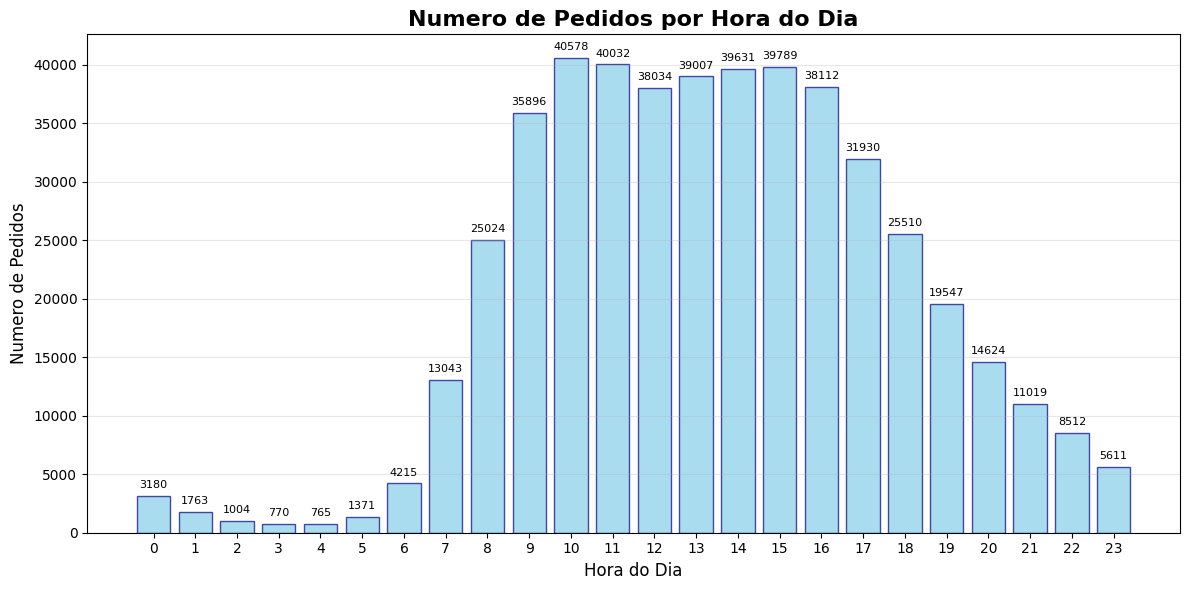

== Estatisticas dos Pedidos por Hora ===
Hora com mais pedidos: 10h (40578 pedidos)
Hora com menos pedidos: 4h (765 pedidos)
Media de pedidos por hora: 19957


In [16]:
import matplotlib.pyplot as plt

pedidos_por_hora = df_instacart_orders['order_hour_of_day'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(pedidos_por_hora.index, pedidos_por_hora.values, color='skyblue', edgecolor='navy', alpha=0.7)
plt.title('Numero de Pedidos por Hora do Dia', fontsize=16, fontweight='bold')
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Numero de Pedidos', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(pedidos_por_hora.values):
    plt.text(i, v + 500, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print('== Estatisticas dos Pedidos por Hora ===')
print(f"Hora com mais pedidos: {pedidos_por_hora.idxmax()}h ({pedidos_por_hora.max()} pedidos)")
print(f"Hora com menos pedidos: {pedidos_por_hora.idxmin()}h ({pedidos_por_hora.min()} pedidos)")
print(f"Media de pedidos por hora: {pedidos_por_hora.mean():.0f}")




Escreva suas conclusões aqui
O horario com mais pedidos e as 10 da manha com 40.578 pedidos, tendo assim mais do dobro da media horaria. mostrando um padrao onde as pessoas tende a fazer compras mas pela parte da manha.
E de madrugada o fluxo de pedido e o menor, tendo apenas 765, que é esperado pelo horario.
Sendo assim o harario de pico tem que seja aproveitado, ajustando a empresa para vender mais: tendo estoque e entregadores.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Pedidos ao longo do dia investigados adequadamente.
</div>


### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

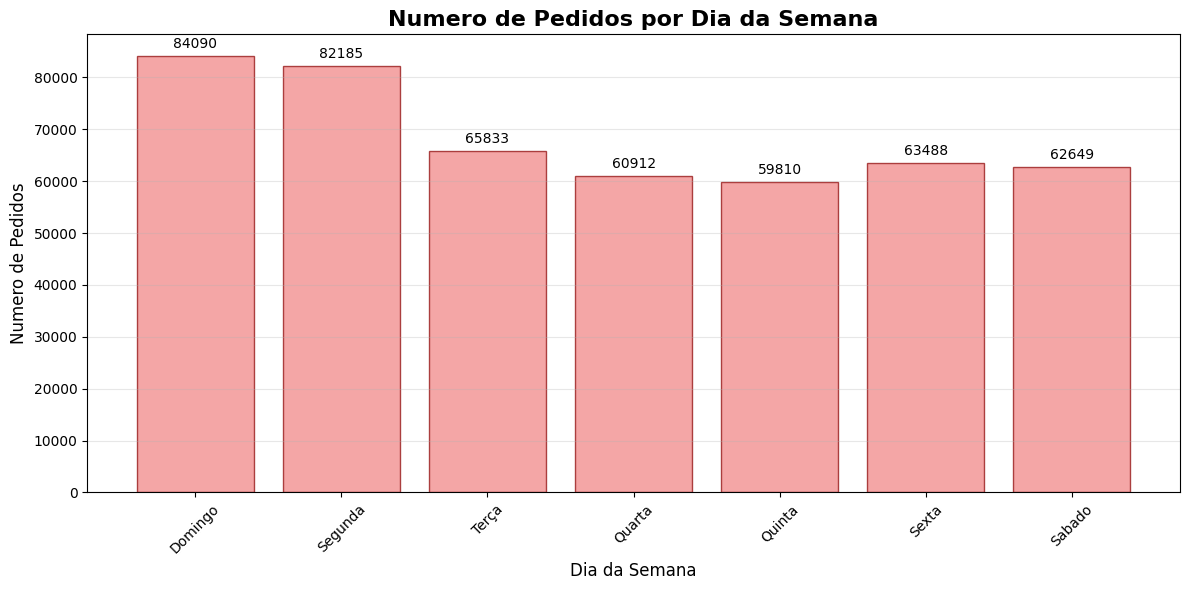

=== Estatistica dos Pedidos por Dia da Semana ===
Dia com mais pedidos: Domingo (84090 pedidos)
Dia com menos pedidos: Quinta (59810 pedidos)
Media de pedidos por dia: 68424


In [21]:
import matplotlib.pyplot as plt
pedidos_por_dia = df_instacart_orders['order_dow'].value_counts().sort_index()

dias_semana = ['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sabado']

plt.figure(figsize=(12, 6))
plt.bar(range(7), pedidos_por_dia.values, color='lightcoral', edgecolor='darkred', alpha=0.7)
plt.title('Numero de Pedidos por Dia da Semana', fontsize=16, fontweight='bold')    
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Numero de Pedidos', fontsize=12)
plt.xticks(range(7), dias_semana, rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(pedidos_por_dia.values):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom', fontsize=10)
    
plt.tight_layout() 
plt.show()

print("=== Estatistica dos Pedidos por Dia da Semana ===")
print(f"Dia com mais pedidos: {dias_semana[pedidos_por_dia.idxmax()]} ({pedidos_por_dia.max()} pedidos)")
print(f"Dia com menos pedidos: {dias_semana[pedidos_por_dia.idxmin()]} ({pedidos_por_dia.min()} pedidos)")
print(f"Media de pedidos por dia: {pedidos_por_dia.mean():.0f}")



    

Escreva suas conclusões aqui
O dia com mais pedidos e no domingo com 84.090, creio que seja devido o inicio da semana, assim ter investimento para melhor atender os clientes.
O dia com menor vendas e na quinta feira com 59.810



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Pedidos diários investigados adequadamente.
</div>


### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui
os dados mostram que o maior tempo sem fazer pedidos e de 30 dias e que varios clientes fazem pedido todo dia, tendo assim uma atenção especial com esse que passam um intervalo maior para reptir os pedidos. mandando lembretes e promoçoes.


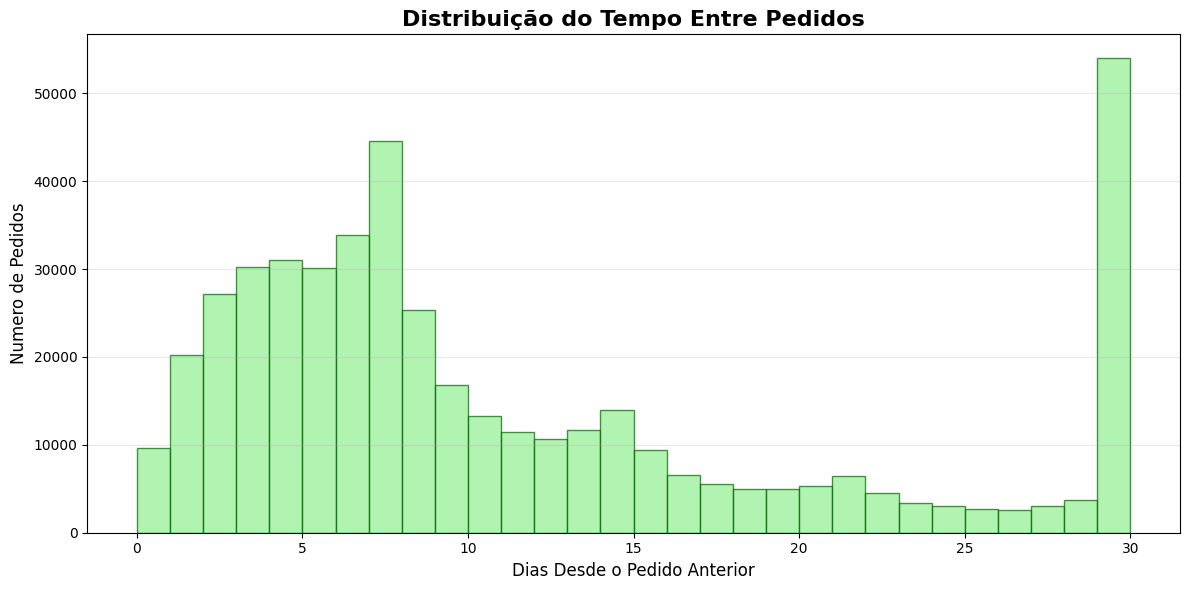

=== Estatisticas do Tempo Entre Pedidos ===
Valor minimo: 0.0 dias
Valor maximo: 30.0 dias
Media:11.1 dias
Mediana:7.0 dias


In [25]:
import matplotlib.pyplot as plt
dias_entre_pedidos = df_instacart_orders['days_since_prior_order'].dropna()

plt.figure(figsize=(12, 6))
plt.hist(dias_entre_pedidos, bins=30, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.title('Distribuição do Tempo Entre Pedidos', fontsize=16, fontweight='bold')
plt.xlabel('Dias Desde o Pedido Anterior', fontsize=12)
plt.ylabel('Numero de Pedidos', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print("=== Estatisticas do Tempo Entre Pedidos ===")
print(f"Valor minimo: {dias_entre_pedidos.min()} dias")
print(f"Valor maximo: {dias_entre_pedidos.max()} dias")
print(f"Media:{dias_entre_pedidos.mean():.1f} dias")
print(f"Mediana:{dias_entre_pedidos.median():.1f} dias")



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tempo entre pedidos foi devidamente investigado.
</div>

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [30]:
import matplotlib.pyplot as plt

pedidos_quarta = df_instacart_orders[df_instacart_orders['order_dow'] == 3]
pedidos_sabado = df_instacart_orders[df_instacart_orders['order_dow'] == 6]

quarta_por_hora = pedidos_quarta['order_hour_of_day'].value_counts().sort_index()
sabado_por_hora = pedidos_sabado['order_hour_of_day'].value_counts().sort_index()


In [34]:
quarta_por_hora = pedidos_quarta['order_hour_of_day'].value_counts().sort_index()
sabado_por_hora = pedidos_sabado['order_hour_of_day'].value_counts().sort_index()

print("Primeiros 5 horas - Quarta:")
print(quarta_por_hora.head())
print("\nPrimeiro 5 horas - sabado:")
print(sabado_por_hora.head())

Primeiros 5 horas - Quarta:
0    373
1    215
2    121
3    101
4    108
Name: order_hour_of_day, dtype: int64

Primeiro 5 horas - sabado:
0    464
1    254
2    177
3    125
4    118
Name: order_hour_of_day, dtype: int64


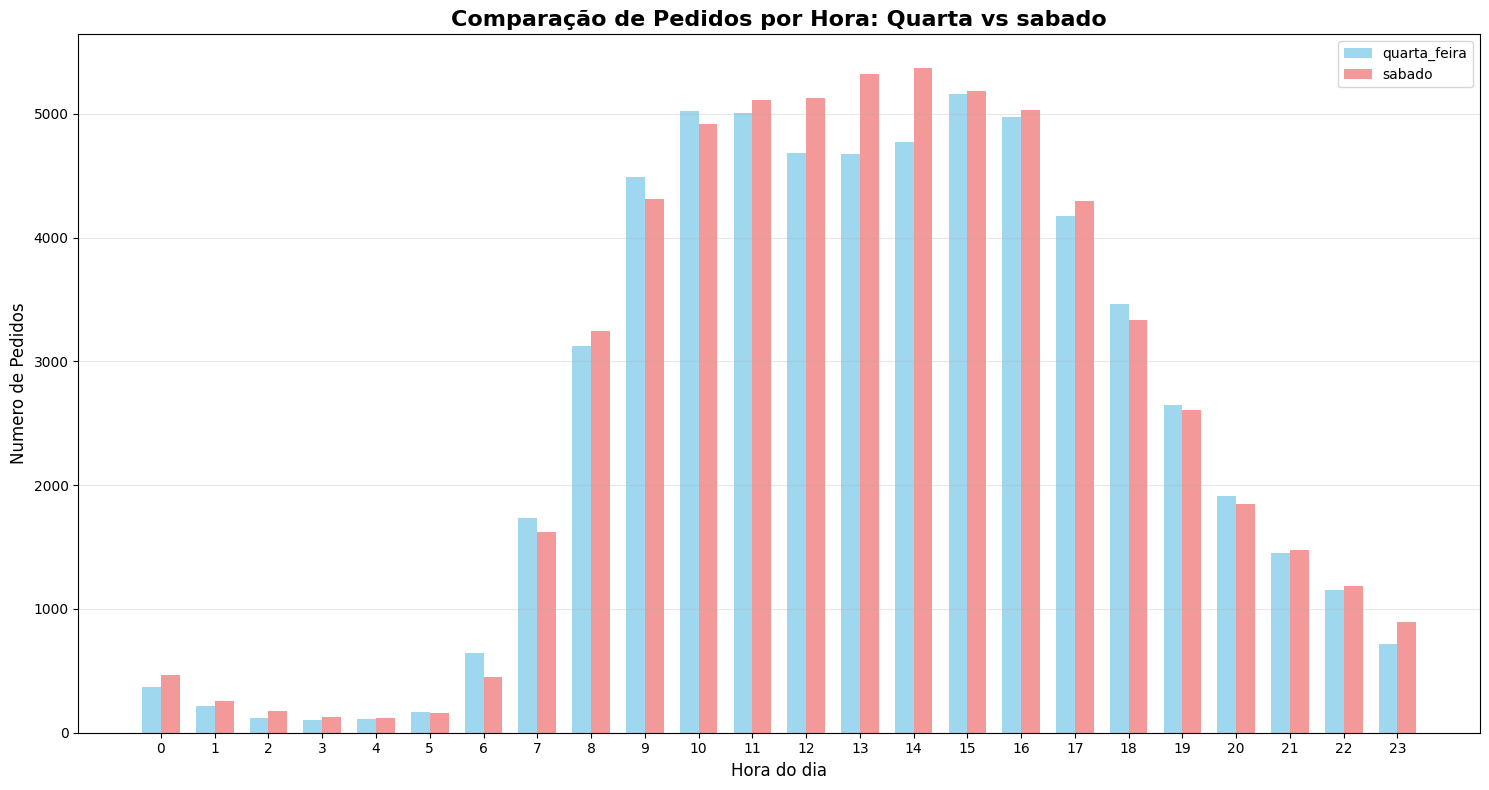

In [36]:
import matplotlib.pyplot as plt
import numpy as np


horas = range(24)
x = np.arange(len(horas))
width = 0.35
quarta_valores = [quarta_por_hora.get(h, 0) for h in horas]
sabado_valores = [sabado_por_hora.get(h, 0) for h in horas]

plt.figure(figsize=(15, 8))
plt.bar(x - width/2, quarta_valores, width, label='quarta_feira', color='skyblue',alpha=0.8)
plt.bar(x + width/2, sabado_valores, width, label='sabado', color='lightcoral', alpha=0.8)

plt.title('Comparação de Pedidos por Hora: Quarta vs sabado', fontsize=16, fontweight='bold')
plt.xlabel('Hora do dia', fontsize=12)
plt.ylabel('Numero de Pedidos', fontsize=12)
plt.xticks(x, horas)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



Escreva suas conclusões aqui
nos sabados a venda e maior em relação ao quarta feira e os dois dias tem picos o parecidos, porem sabado tem um volume bem maior durante o dia.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Ótimo, comparativo entre os dias foi conduzido com gráfico e conclusão de acordo com o esperado.
</div>


### [B2] Qual é a distribuição do número de pedidos por cliente?

In [42]:
pedidos_por_cliente = df_instacart_orders.groupby('user_id').size()
distribuicao_pedidos = pedidos_por_cliente.value_counts().sort_index()

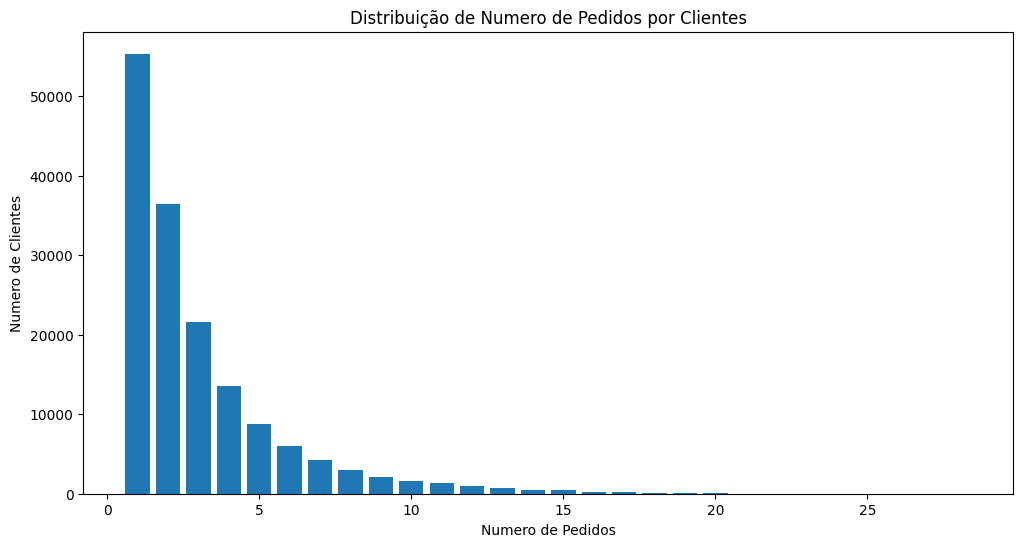

In [43]:
plt.figure(figsize=(12, 6))
plt.bar(distribuicao_pedidos.index, distribuicao_pedidos.values)
plt.title('Distribuição de Numero de Pedidos por Clientes')
plt.xlabel('Numero de Pedidos')
plt.ylabel('Numero de Clientes')
plt.show()
    

Escreva suas conclusões aqui
o grafico esta em distribuição descrescente, entao a maioria dos clintes fazem um meia grande de pedidos.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Distribuição dos pedidos por clientes avaliada
</div>

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [44]:
df_order_products.head()


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [45]:
product_counts = df_order_products['product_id'].value_counts()
print(product_counts.head(10))

24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
Name: product_id, dtype: int64


In [47]:
top_20_products = product_counts.head(20)
print("Top 20 produtos por ID:")
print(top_20_products)

Top 20 produtos por ID:
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: product_id, dtype: int64


In [50]:
top_20_df = top_20_products.reset_index()
top_20_df.columns = ['product_id', 'count']

top_20_com_nome = top_20_df.merge(df_products[['product_id', 'product_name']], on='product_id')

print("=== Top 20 Produtos Mais Populares ===")
print(top_20_com_nome[['product_id', 'product_name', 'count']])

=== Top 20 Produtos Mais Populares ===
    product_id              product_name  count
0        24852                    Banana  66050
1        13176    Bag of Organic Bananas  53297
2        21137      Organic Strawberries  37039
3        21903      Organic Baby Spinach  33971
4        47209      Organic Hass Avocado  29773
5        47766           Organic Avocado  24689
6        47626               Large Lemon  21495
7        16797              Strawberries  20018
8        26209                     Limes  19690
9        27845        Organic Whole Milk  19600
10       27966       Organic Raspberries  19197
11       22935      Organic Yellow Onion  15898
12       24964            Organic Garlic  15292
13       45007          Organic Zucchini  14584
14       39275       Organic Blueberries  13879
15       49683            Cucumber Kirby  13675
16       28204        Organic Fuji Apple  12544
17        5876             Organic Lemon  12232
18        8277  Apple Honeycrisp Organic  11993
1

Escreva suas conclusões aqui
os tres produtos mais populares:
banana com 66.050
bag of organic bananas 53.297
organic strawberries 37.039
levando para clinet


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Produtos selecionados corretamente.
</div>


# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [3]:
itens_por_pedido = df_order_products.groupby('order_id').size()
distribuicao_itens = itens_por_pedido.value_counts().sort_index()

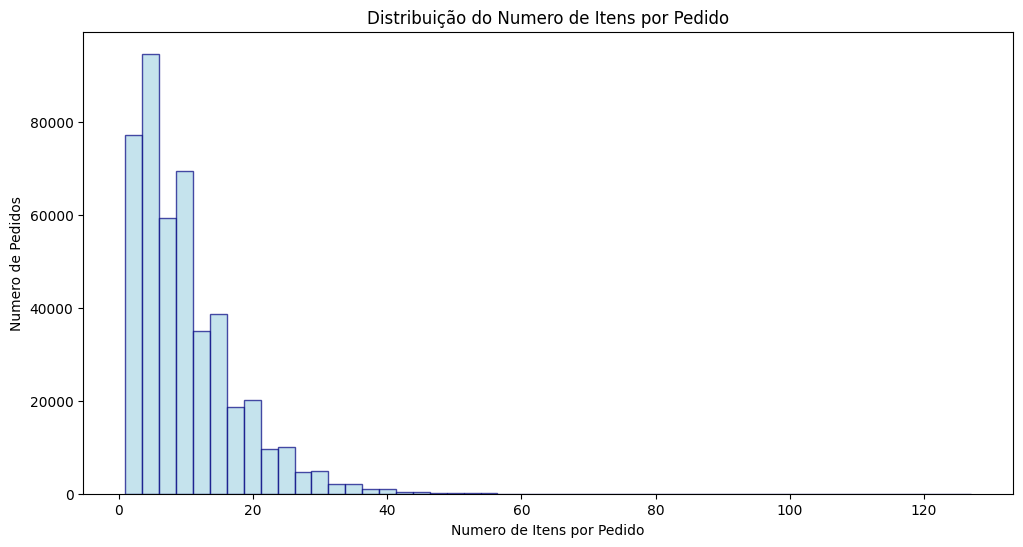

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.hist(itens_por_pedido, bins=50, color='lightblue', edgecolor='navy', alpha=0.7)
plt.title('Distribuição do Numero de Itens por Pedido')
plt.xlabel('Numero de Itens por Pedido')
plt.ylabel('Numero de Pedidos')
plt.show()

    

In [9]:
print("=== Estatisticas dos Itens por Pedido ===")
print(f"Minimo: {itens_por_pedido.min()} itens")
print(f"Maximo: {itens_por_pedido.max()} itens")
print(f"Media: {itens_por_pedido.mean():.1f} itens")
print(f"Mediana: {itens_por_pedido.median():.1f} itens")

=== Estatisticas dos Itens por Pedido ===
Minimo: 1 itens
Maximo: 127 itens
Media: 10.1 itens
Mediana: 8.0 itens


Escreva suas conclusões aqui
A maioria do pedidos contem poucos itens, tendo uma media de 8 produtos por pedidos, sendo assim 50% dos pedidos tem 8 ou menos itens.
o maximo de itens por pedidos foi fr 127, a analise mostra que oque lidera as compras online sao pedidos entre 1-10 itens.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Itens por pedido avaliados adequadamente.
</div>


### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [10]:
df_order_products['reordered'].value_counts()

1    2683838
0    1861169
Name: reordered, dtype: int64

In [17]:

produtos_reordenados = df_order_products[df_order_products['reordered'] == 1]

product_counts = df_order_products['product_id'].value_counts()
print(product_counts.head(1))



24852    66050
Name: product_id, dtype: int64


In [18]:
produtos_reordenados_counts = produtos_reordenados['product_id'].value_counts()
print("Top 20 produtos reordenados:")
print(produtos_reordenados_counts.head(20))


Top 20 produtos reordenados:
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
26209    13327
22935    11145
24964    10411
45007    10076
49683     9538
28204     8989
8277      8836
39275     8799
5876      8412
49235     8389
Name: product_id, dtype: int64


In [23]:
top_20_reordenados = produtos_reordenados_counts.head(20).reset_index()
top_20_reordenados.columns = ['product_id', 'count']

top_20_reordenados_com_nome = top_20_reordenados.merge(
    df_products[['product_id', 'product_name']], 
    on='product_id'
)

print("=== Top 20 produtos Mais Reordenados ===")
print(top_20_reordenados_com_nome[['product_id', 'product_name', 'count']])


=== Top 20 produtos Mais Reordenados ===
    product_id              product_name  count
0        24852                    Banana  55763
1        13176    Bag of Organic Bananas  44450
2        21137      Organic Strawberries  28639
3        21903      Organic Baby Spinach  26233
4        47209      Organic Hass Avocado  23629
5        47766           Organic Avocado  18743
6        27845        Organic Whole Milk  16251
7        47626               Large Lemon  15044
8        27966       Organic Raspberries  14748
9        16797              Strawberries  13945
10       26209                     Limes  13327
11       22935      Organic Yellow Onion  11145
12       24964            Organic Garlic  10411
13       45007          Organic Zucchini  10076
14       49683            Cucumber Kirby   9538
15       28204        Organic Fuji Apple   8989
16        8277  Apple Honeycrisp Organic   8836
17       39275       Organic Blueberries   8799
18        5876             Organic Lemon   8412

Escreva suas conclusões aqui
os produtos com mas saida são os produtos frescos como: banana(55.763), bag of organic bananas(44.450) e orgaic strawberries(28.639).
produtos sempre em rotação; frutas e vegetais dominam a lista, e produtos basicos como:leite,limao e cebola sempre aparacem com frequencia.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Produtos selecionados corretamente.
</div>


### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [10]:
total_por_produto = df_order_products.groupby('product_id').size()
reordenacoes_por_produto = df_order_products[df_order_products['reordered'] == 1].groupby('product_id').size()
proporcao_reordenacoes = reordenacoes_por_produto / total_por_produto
proporcao_reordenacoes = proporcao_reordenacoes.fillna(0)
resultado = pd.DataFrame({
    'product_id': proporcao_reordenacoes.index,
    'proporcao_reordenacoes':proporcao_reordenacoes.values
})

resultado = resultado.merge(df_products[['product_id', 'product_name']], on='product_id')

print("=== Proporçao de Reordenaçoes por Produto ===")
print(resultado.head(10))


=== Proporçao de Reordenaçoes por Produto ===
   product_id  proporcao_reordenacoes  \
0           1                0.564286   
1           2                0.000000   
2           3                0.738095   
3           4                0.510204   
4           7                0.500000   
5           8                0.315789   
6           9                0.761905   
7          10                0.448071   
8          11                0.625000   
9          12                0.390244   

                                        product_name  
0                         Chocolate Sandwich Cookies  
1                                   All-Seasons Salt  
2               Robust Golden Unsweetened Oolong Tea  
3  Smart Ones Classic Favorites Mini Rigatoni Wit...  
4                     Pure Coconut Water With Orange  
5                  Cut Russet Potatoes Steam N' Mash  
6                  Light Strawberry Blueberry Yogurt  
7     Sparkling Orange Juice & Prickly Pear Beverage  
8      

In [9]:
resultado_ordenado = resultado.sort_values('proporcao_reordenacoes', ascending=False)
print("=== Top 10 Produtos com Maior Proporção de Reordenação ===")
print(resultado_ordenado.head(10))

=== Top 10 Produtos com Maior Proporção de Reordenação ===
       product_id  proporcao_reordenacoes  \
13453       14721                     1.0   
19195       20949                     1.0   
6136         6723                     1.0   
6144         6732                     1.0   
41319       45088                     1.0   
41310       45078                     1.0   
19258       21016                     1.0   
19248       21005                     1.0   
32273       35192                     1.0   
32277       35197                     1.0   

                                            product_name  
13453                            Bone Strength Take Care  
19195                           Vanilla Sandwich Cookies  
6136                                    Palmiers- Petite  
6144                   Naturally Sparkling Mineral Water  
41319  California Dill Pollen & Garlic Goat Cheese & ...  
41310                                       Pomegranatea  
19258       Parchment Lined 8 in

In [11]:
produtos_100_porcento = resultado_ordenado[resultado_ordenado['proporcao_reordenacoes'] == 1.0]
print(f"Numero de produtos com 100% de reordenaçao: {len(produtos_100_porcento)}")

resultado_com_volume = resultado.merge(
    df_order_products.groupby('product_id').size().reset_index(name='total_pedidos'),
    on='product_id'
)

produtos_relevantes = resultado_com_volume[
    (resultado_com_volume['total_pedidos'] >= 100) &
    (resultado_com_volume['proporcao_reordenacoes'] >= 0.8)
].sort_values('proporcao_reordenacoes', ascending=False)
print("=== Produtos com alta Reordenacao E Volume Significativo ===")
print(produtos_relevantes[['product_name', 'proporcao_reordenacoes', 'total_pedidos']].head(10))





Numero de produtos com 100% de reordenaçao: 1809
=== Produtos com alta Reordenacao E Volume Significativo ===
                            product_name  proporcao_reordenacoes  \
8483     Half And Half Ultra Pasteurized                0.876574   
2450   Yerba Mate Sparkling Classic Gold                0.871345   
43292               Ultra-Purified Water                0.868293   
1046                Wheat Sandwich Bread                0.863946   
41704         Whole Organic Omega 3 Milk                0.863142   
27013           Milk- Organic- Vitamin D                0.862847   
31363                          Goat Milk                0.859135   
5045      Organic Homogenized Whole Milk                0.857664   
29094                Organic  Whole Milk                0.855137   
22498                   Lowfat Goat Milk                0.853801   

       total_pedidos  
8483             397  
2450             171  
43292            205  
1046             147  
41704           1286  
270

In [12]:
print("=== CONCLUSÃO DA ANALISE C3 ===")
print(f"Total de produtos analisados: {len(resultado)}")
print(f"Produtos com 100% de reordenação: {len(produtos_100_porcento)}")
print(f"Produtos com alta reordenação E volume significativo: {len(produtos_relevantes)}")
print("\nPadroes identificados:")
print("1. Produtos com 100% reordenação geralmenre tem baixo colume")
print("2. Produtos basicos (frutas, vegetais, laticinios) tem alta taxa de reordenação")
print("3. Consumidores tendem a repetir compras de itens essenciais")


=== CONCLUSÃO DA ANALISE C3 ===
Total de produtos analisados: 45573
Produtos com 100% de reordenação: 1809
Produtos com alta reordenação E volume significativo: 77

Padroes identificados:
1. Produtos com 100% reordenação geralmenre tem baixo colume
2. Produtos basicos (frutas, vegetais, laticinios) tem alta taxa de reordenação
3. Consumidores tendem a repetir compras de itens essenciais


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Taxas calculadas corretamente.
</div>


### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [19]:
pedidos_com_produtos = df_order_products.merge(df_instacart_orders[['order_id', 'user_id']], on='order_id')
total_produtos_por_cliente = pedidos_com_produtos.groupby('user_id').size()                                              
produtos_reordenados_por_cliente = pedidos_com_produtos[pedidos_com_produtos['reordered'] == 1].groupby('user_id').size()                                              
proporcao_por_cliente = produtos_reordenados_por_cliente / total_produtos_por_cliente                                              
proporcao_por_cliente = proporcao_por_cliente.fillna(0)                                              
                                              

=== ANALISE C4: Proporção de Reordenaçoes por Cliente ===
Numero total de clientes analisados: 149626
Proporção media de reordenações: 0.495
Proporção mediana: 0.500
Proporção minima: 0.000
Proporção maxima: 1.000


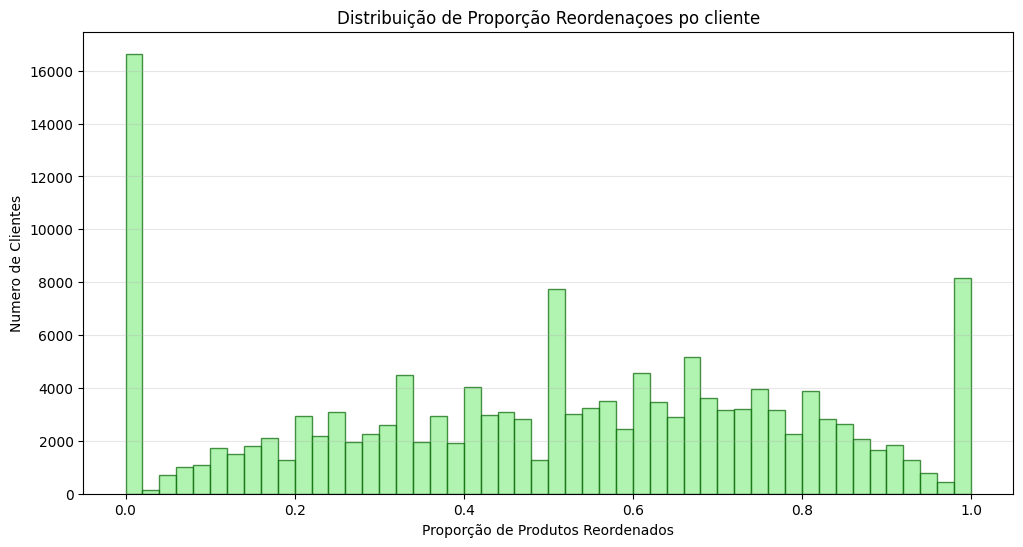

In [21]:
print("=== ANALISE C4: Proporção de Reordenaçoes por Cliente ===")
print(f"Numero total de clientes analisados: {len(proporcao_por_cliente)}")
print(f"Proporção media de reordenações: {proporcao_por_cliente.mean():.3f}")
print(f"Proporção mediana: {proporcao_por_cliente.median():.3f}")
print(f"Proporção minima: {proporcao_por_cliente.min():.3f}")
print(f"Proporção maxima: {proporcao_por_cliente.max():.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(proporcao_por_cliente, bins=50, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.title('Distribuição de Proporção Reordenaçoes po cliente')
plt.xlabel('Proporção de Produtos Reordenados')
plt.ylabel('Numero de Clientes')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [22]:
print("=== C0NCLUSÃO DA ANALISE C4 ===")
print("Comportamento dos Clientes:")
print("1. Clientes medio reordena cerca de 50% dos produtos que compra")
print("2. Distribuição equilibrada: metade dos clientes reordena mais de 50%")
print("3. Ha clinetes extremos: alguns nunca reordenam (0%) e outros sempre reodenam (100%)")
print("4. A maioria dos clientes tem comportamento misto: combina produtos habituais com novidades")
print("\nImplicações para o negaocio:")
print("_ Oportunidade de recomendar produtos baseados no historico")
print("_ Clientes com baixa reordenação podem precisar de incentivo especias")

=== C0NCLUSÃO DA ANALISE C4 ===
Comportamento dos Clientes:
1. Clientes medio reordena cerca de 50% dos produtos que compra
2. Distribuição equilibrada: metade dos clientes reordena mais de 50%
3. Ha clinetes extremos: alguns nunca reordenam (0%) e outros sempre reodenam (100%)
4. A maioria dos clientes tem comportamento misto: combina produtos habituais com novidades

Implicações para o negaocio:
_ Oportunidade de recomendar produtos baseados no historico
_ Clientes com baixa reordenação podem precisar de incentivo especias


Escreva suas conclusões aqui
149.626 clientes foram analisados e desse a proporção media e de 49,5% dos produtos sao reordenações e na proporção mediana e de 50%s sendo a metade dos clientes.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Taxas calculadas corretamente.
</div>


### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [23]:
primeiros_itens = df_order_products[df_order_products['add_to_cart_order'] == 1]

contagem_primeiros = primeiros_itens['product_id'].value_counts()
top_20_primeiros = contagem_primeiros.head(20)
print("=== ANALISE C5: TOP 20 PRIMEIROS ITENS NO CARRINHO ===")
print(f"Total unicos que foram primeiro item: {len(contagem_primeiros)}")





=== ANALISE C5: TOP 20 PRIMEIROS ITENS NO CARRINHO ===
Total unicos que foram primeiro item: 26760


In [26]:
top_20_primeiros_df = top_20_primeiros.reset_index()
top_20_primeiros_df.columns = ['product_id', 'count']
top_20_primeiro_com_nome = top_20_primeiros_df.merge(
    df_products[['product_id', 'product_name']],
    on='product_id'
)

print("=== Top 20 produtos Mais adicionados Primeiro ao Carrinho ===")
for i, row in top_20_primeiro_com_nome.iterrows():
    print(f"{i+1:2d}. {row['product_name']} (ID: {row['product_id']}) - {row['count']} vezes")



=== Top 20 produtos Mais adicionados Primeiro ao Carrinho ===
 1. Banana (ID: 24852) - 15562 vezes
 2. Bag of Organic Bananas (ID: 13176) - 11026 vezes
 3. Organic Whole Milk (ID: 27845) - 4363 vezes
 4. Organic Strawberries (ID: 21137) - 3946 vezes
 5. Organic Hass Avocado (ID: 47209) - 3390 vezes
 6. Organic Baby Spinach (ID: 21903) - 3336 vezes
 7. Organic Avocado (ID: 47766) - 3044 vezes
 8. Spring Water (ID: 19660) - 2336 vezes
 9. Strawberries (ID: 16797) - 2308 vezes
10. Organic Raspberries (ID: 27966) - 2024 vezes
11. Sparkling Water Grapefruit (ID: 44632) - 1914 vezes
12. Organic Half & Half (ID: 49235) - 1797 vezes
13. Large Lemon (ID: 47626) - 1737 vezes
14. Soda (ID: 196) - 1733 vezes
15. Organic Reduced Fat Milk (ID: 38689) - 1397 vezes
16. Limes (ID: 26209) - 1370 vezes
17. Hass Avocados (ID: 12341) - 1340 vezes
18. Organic Reduced Fat 2% Milk (ID: 5785) - 1310 vezes
19. Half & Half (ID: 27086) - 1309 vezes
20. Organic Yellow Onion (ID: 22935) - 1246 vezes


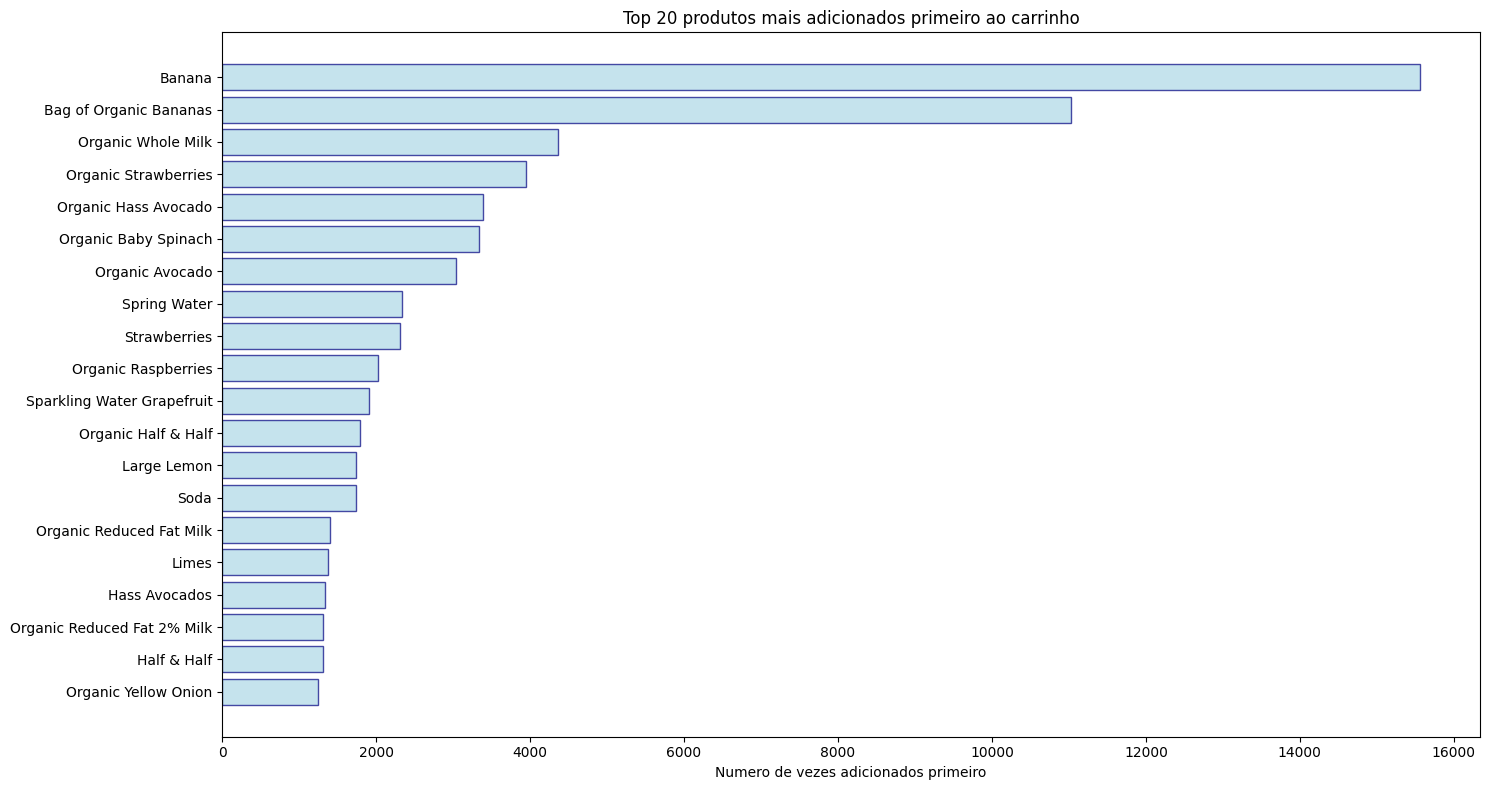

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
plt.barh(range(len(top_20_primeiro_com_nome)), top_20_primeiro_com_nome['count'],
        color='lightblue', edgecolor='navy', alpha=0.7)
plt.yticks(range(len(top_20_primeiro_com_nome)),
          [f"{row['product_name'][:30]}..." if len(row['product_name']) >30
           else row['product_name'] for i, row in top_20_primeiro_com_nome.iterrows()])
plt.xlabel('Numero de vezes adicionados primeiro')
plt.title('Top 20 produtos mais adicionados primeiro ao carrinho')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()










Escreva suas conclusões aqui
notasse que a banana e o produto mais adicionado com (15.562 vezes) em segundo vem o bag of organic bananas em segundo com (11.026 vezes)e em terceiro organic whole milk com(4.363), pois normalmente as pessoas comecam as suas compras com itens essenciais como frutas e leite.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Produtos selecionados corretamente.
</div>


# Conclusão geral do projeto:

Com a analise foi possovil ver padroes de compras como o horario e pico que e as 10 da manha com 40.578 que e bem mais que o dobro da media horaria e o horario com menor venda e na madrugada, e o dia com maior movimento e no domingo 84.090 pedidos, pessoas tentando organizar suas semanas.
Comportamento dos clientes: media de itens e de 10,1 por produtos uma media de 8 produtos, com um intervalo entre pedidos media de 11,1 dias, mediana de 7 dias. com uma taxa de recompra de 50% dos produtos comprados são de reordenações.
Os produtos lideres em venda sao principalmente os organicos; banana com 66.050 de vendas, bag of organic banana 53.297, produtos frescos como frutas e vegetais e lacticinios.
Depois da analise temos dados limpos, foi removido 15 duplicatas do sistema e os valores ausentes foram tratados os 1.258 produtos sem nome foi categorizados como Unknown, e as limitação do sistema registrando ate 64 itens por pedido foi identificada.
Assim temos uma visao do melhor horario e dia pra se investir e sobre quais produtos tem saida e o melhor dia pra ser fazer promoçoes e focar no estoque baseado nos padroes de compras.





